### Context and structure of the notebook

This notebook applies descriptive and inferential statistics to compare Ireland’s agricultural indicators with selected peer countries.

* Loads and checks the prepared agricultural dataset
* Calculates descriptive statistics for selected numeric features
* Examines feature distributions, skewness, outliers and normality
* Calculates confidence intervals for Ireland’s recent agricultural indicators
* Compares Ireland with clustering-based peer countries using Welch’s t-test and Mann-Whitney U tests
* Applies ANOVA to test differences across Ireland and selected comparison countries
* Uses a Chi-square test to examine association between country group and export-profile category

In [47]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy import stats
from scipy.stats import shapiro

import warnings
warnings.filterwarnings('ignore') # supress the warnings

### Load and preview the aggregated dataset

This data set was prepared for clustering by aggregating FAOSTAT production, export and land use data sets for recent years.

In [6]:
# read the cleaned csv file
df = pd.read_csv("country_cluster_clean.csv")
df.head()

,country_code,country_name,cereals_n_e_c_share_cropland,meat_of_goat_export_value_share,meat_of_goat_prod_t_per_pasture_ha,oats_share_cropland,goats_export_value_share,oats_yield_kg_per_ha,swine_per_pigs_export_value_share,oats_total_export_value_share,...,vegetables_primary_yield_kg_per_ha,wheat_yield_kg_per_ha,cattle_stocks_per_pasture_ha,sheep_stocks_per_pasture_ha,goats_stocks_per_pasture_ha,chickens_stocks_per_agri_land_ha,swine_stocks_per_agri_land_ha,meat_of_sheep_prod_t_per_pasture_ha,pasture_share_agri_land,dairy_products_total_export_value_share
0,32,Argentina,0.000623,8.366176e-06,0.100579,0.006409,8.600989e-08,2138.622222,2.706893e-06,0.000024,...,21248.477778,2975.033333,711.147315,185.659348,59.498062,980.885241,44.965460,0.647403,0.642700,0.020170
1,36,Australia,0.000000,4.228594e-03,0.084359,0.026762,1.246232e-04,1631.344444,6.231316e-07,0.003451,...,26408.855556,2320.988889,78.669116,210.390112,11.248691,283.131186,6.735344,2.187876,0.913046,0.042160
2,40,Austria,0.007498,2.484246e-07,0.552426,0.015415,6.655220e-05,3810.355556,2.601049e-04,0.000565,...,35278.400000,5626.611111,1528.341095,311.590072,72.072636,6392.821507,1044.809756,5.256979,0.470803,0.068638
3,56,Belgium,0.003205,8.021801e-06,0.731195,0.004173,6.513144e-06,5044.988889,3.346540e-03,0.000455,...,32930.488889,8607.244444,4998.419831,213.700911,106.978633,34974.440248,4469.953178,5.390249,0.351128,0.068601
4,76,Brazil,0.000000,1.566682e-07,0.204840,0.006914,3.016865e-09,2030.877778,4.332203e-05,0.000020,...,24857.800000,2667.322222,1278.549534,114.709228,65.149872,6176.974857,175.779599,0.568070,0.732121,0.001173


### View dimensions of dataset

In [3]:
df.shape

(37, 49)

Data set contains 37 countries and 47 numeric features.

In [5]:
# Which countries' observations are present in the dataset:
df['country_name'].unique()

array(['Argentina', 'Australia', 'Austria', 'Belgium', 'Brazil',
       'Bulgaria', 'Canada', 'China', 'Croatia', 'Cyprus', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'India', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
       'Luxembourg', 'Netherlands (Kingdom of the)', 'New Zealand',
       'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain',
       'Sweden', 'Thailand',
       'United Kingdom of Great Britain and Northern Ireland',
       'United States of America', 'Uruguay'], dtype=object)

It's EU (26 countries, excluding Malta), UK, USA, Canada, Australia, New Zealand, Argentina, Brazil, Uruguay, China, India, Thailand. Countries outside the EU were selected based on their strong livestock/dairy/crop/agricultural exporters profiles.

### View summary of dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 49 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   country_code                              37 non-null     int64  
 1   country_name                              37 non-null     object 
 2   cereals_n_e_c_share_cropland              37 non-null     float64
 3   meat_of_goat_export_value_share           37 non-null     float64
 4   meat_of_goat_prod_t_per_pasture_ha        37 non-null     float64
 5   oats_share_cropland                       37 non-null     float64
 6   goats_export_value_share                  37 non-null     float64
 7   oats_yield_kg_per_ha                      37 non-null     float64
 8   swine_per_pigs_export_value_share         37 non-null     float64
 9   oats_total_export_value_share             37 non-null     float64
 10  chickens_export_value_share             

- Data consists of cropland shares, export shares for crop and livistock products, yields per ha, crop and livistock stocks/products shares per pasture/agri lands
- `country_code` variable has integer data type and `country_name` variable has object (string) data type as expected
- All the other variables (numeric features) are of float data type.
- There are no missing values, as the dataset was already cleaned and prepared for the further analysis (and we can also see that there are 37 non-null values for each variable and 37 observations (countries) in total).

## Descriptive statistics

To determine appropriate scalers/standardisers for numeric variables, we need to first check variables distributions, outliers and skewness

In [8]:
# define identifier columns (country_name, country_code)
id_cols = ["country_code", "country_name"]
# drop identifier columns
X = df.drop(columns=id_cols, errors="ignore")

# keep numeric features only
X = X.select_dtypes(include="number")

print("Number of features:", X.shape[1])
print("Number of countries:", X.shape[0])

Number of features: 47
Number of countries: 37


Create the descriptive statustics table with:
- measures of central tendencies* (mean, median)
- measures of dispersion or variability (min, max, range, variance, standard deviation, Q1, Q3, IQR)
- measures of shape of distribution (skewness, kurtosis)

**For continuous variables, mode is not informative. If every value is unique, then technically there is no meaningful mode. Therefore, its calculation was skipped.*

In [13]:
distribution_rows = []

for col in X.columns:
    s = X[col].dropna()

    # basic statistics
    mean_val = s.mean()
    median_val = s.median()
    min_val = s.min()
    max_val = s.max()
    range_val = s.max() - s.min()
    var_val = s.var()
    std_val = s.std()

    # skewness
    skew_val = s.skew()

    if abs(skew_val) < 0.5:
        skew_class = "slightly skewed"
    elif abs(skew_val) < 1:
        skew_class = "moderately skewed"
    elif abs(skew_val) < 2:
        skew_class = "highly skewed"
    else:
        skew_class = "very highly skewed"

    # IQR outlier detection
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    # determine outliers with Tukey’s method
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    # as points that fall below Q1–1.5*IQR or above Q3+1.5*IQR
    outlier_mask = (s < lower_bound) | (s > upper_bound)
    # count the number of outliers
    outlier_count = outlier_mask.sum()
    # calculate the share of outliers
    outlier_pct = outlier_count / len(s) * 100

    # normality check
    # with only 37 countries, this is useful as a guide, not an absolute rule
    shapiro_stat, shapiro_p = shapiro(s)

    distribution_rows.append({
        "feature": col,
        "mean": mean_val,
        "median": median_val,
        "min": min_val,
        "max": max_val,
        "range": range_val,
        "variance": var_val,
        "std": std_val,
        "skewness": skew_val,
        "abs_skewness": abs(skew_val),
        "skew_class": skew_class,
        "iqr_outlier_count": outlier_count,
        "iqr_outlier_pct": outlier_pct,
        "shapiro_p": shapiro_p
    })

distribution_check = pd.DataFrame(distribution_rows)

# sort by strongest warning signs first (most number of outliers and skewness)
distribution_check = distribution_check.sort_values(
    by=["iqr_outlier_count", "abs_skewness"],
    ascending=[False, False]
)

distribution_check

,feature,mean,median,min,max,range,variance,std,skewness,abs_skewness,skew_class,iqr_outlier_count,iqr_outlier_pct,shapiro_p
1,meat_of_goat_export_value_share,0.000186,0.000006,0.000000e+00,0.004229,0.004229,4.972977e-07,0.000705,5.558306,5.558306,very highly skewed,7,18.918919,2.497547e-12
27,milk_prod_t_per_pasture_ha,181.930610,16.377283,0.000000e+00,3817.134122,3817.134122,4.053516e+05,636.672274,5.483673,5.483673,very highly skewed,7,18.918919,3.756332e-12
7,oats_total_export_value_share,0.003122,0.000379,0.000000e+00,0.047398,0.047398,6.744251e-05,0.008212,4.679401,4.679401,very highly skewed,7,18.918919,4.230466e-11
2,meat_of_goat_prod_t_per_pasture_ha,36.942402,0.256385,0.000000e+00,1220.508768,1220.508768,4.034731e+04,200.866390,6.003148,6.003148,very highly skewed,6,16.216216,4.087308e-13
18,sheep_export_value_share,0.001505,0.000100,8.055284e-08,0.028156,0.028156,2.248511e-05,0.004742,5.240165,5.240165,very highly skewed,6,16.216216,8.837791e-12
19,dairy_prod_t_per_pasture_ha,922.606914,171.898357,7.913809e-01,14716.689601,14715.898220,6.282421e+06,2506.475722,4.956209,4.956209,very highly skewed,6,16.216216,2.213611e-11
9,meat_of_cattle_prod_t_per_pasture_ha,304.254892,72.727374,0.000000e+00,4004.228023,4004.228023,6.150535e+05,784.253459,4.082502,4.082502,very highly skewed,5,13.513514,2.429871e-11
11,meat_of_sheep_export_value_share,0.006978,0.000449,1.347484e-07,0.101061,0.101061,3.959728e-04,0.019899,3.937164,3.937164,very highly skewed,5,13.513514,3.041567e-11
39,cattle_stocks_per_pasture_ha,4167.696330,1129.036325,7.866912e+01,39956.858404,39878.189288,8.426906e+07,9179.817865,3.475545,3.475545,very highly skewed,5,13.513514,8.293435e-11
32,vegetables_primary_share_cropland,0.022078,0.011666,2.365028e-03,0.181611,0.179246,1.124910e-03,0.033540,3.422539,3.422539,very highly skewed,5,13.513514,5.400299e-09


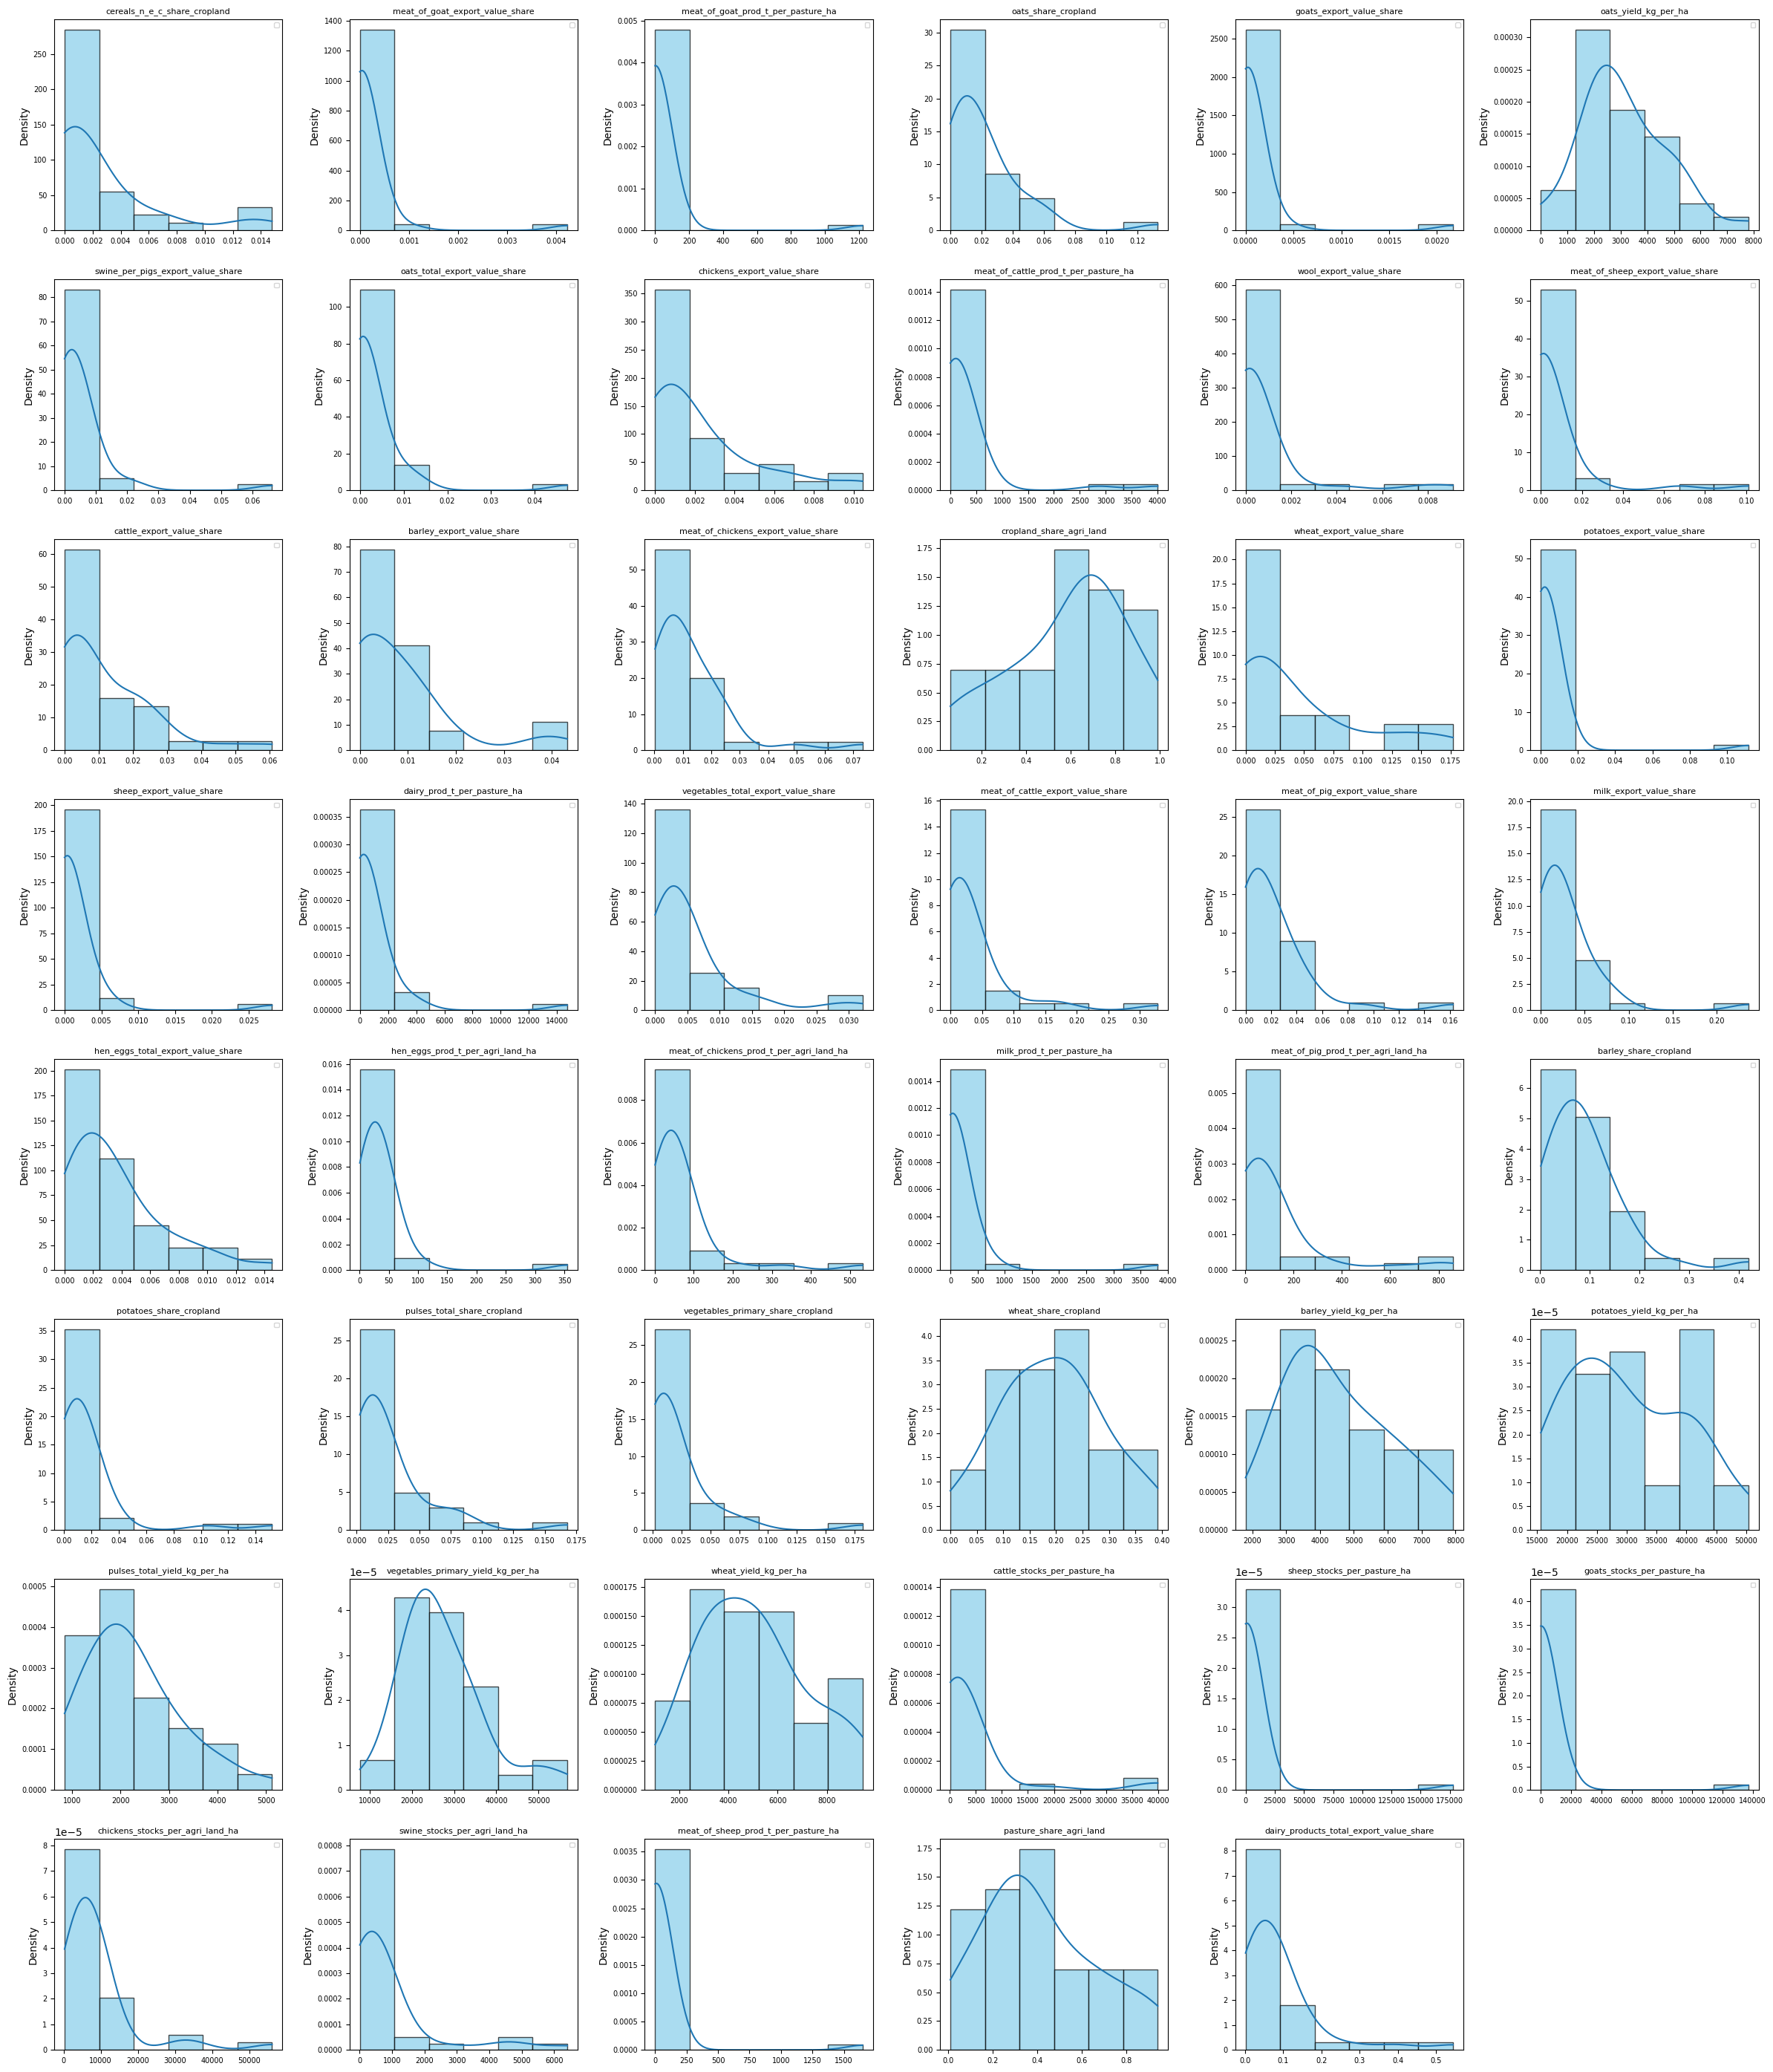

In [115]:
# plot the distributions for all numeric features
features = list(X.columns)

# create one large grid: 8 rows x 6 columns = 48 slots
fig, axes = plt.subplots(8, 6, figsize=(24, 28))
axes = axes.flatten()

# Loop through features and corresponding subplot axes
for ax, col in zip(axes, features):
    # select non-missing values for the current feature
    x = X[col].dropna()
    
    # get this feature's summary row from distribution_check
    row = distribution_check.loc[distribution_check["feature"] == col].iloc[0]
    
    # plot histogram
    ax.hist(x, bins=6, density=True, color="skyblue", edgecolor="black", alpha=0.7)
    
    # add KDE curve only if the data has enough variation
    if len(x) > 1 and x.nunique() > 1:
        kde = gaussian_kde(x)
        x_grid = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_grid, kde(x_grid), linewidth=1.5)
    
    ax.set_title(col, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("Density")
    ax.tick_params(axis="both", labelsize=7)
    ax.legend(fontsize=6)

# hide the unused subplot because there are 47 features and 48 grid slots
for ax in axes[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Among 47 numeric features we have:
- 33 very highly skewed features (`abs(skewness) > 2`)
- 6 highly skewed features (`abs(skewness) between 1 and 2`)
- 41 features with IQR outliers
- 39 features that both highly skewed and have outliers
- 6 features with no IQR outliers and not strongly skewed

Most features are not normally distributed. The majority are strongly right-skewed and contain IQR-detected outliers.

## Inferential statistics: Ireland compared with clustering-based peer countries

The purpose of this section is to test whether Ireland is statistically similar to, or different from, its clustering-based peers on selected agricultural indicators. The analysis uses annual country-level observations from 2015 to 2023, matching the period used for clustering.

For clustering, averaging by country was correct because clustering needed one row per country. But for inferential statistics, the annual data is better because it gives us variation over time. The only caveat is that yearly observations are not perfectly independent, so we use the tests as exploratory inferential comparisons using annual observations, not as perfect population-level causal inference.

### Load and preview raw dataset

In [69]:
raw_df = pd.read_csv("recent_cluster_df.csv")
raw_df.head(10)

,country_code,country_name,year,cropland_share_agri_land,pasture_share_agri_land,barley_share_cropland,cereals_n_e_c_share_cropland,oats_share_cropland,potatoes_share_cropland,pulses_total_share_cropland,...,swine_per_pigs_export_value_share,wheat_export_value_share,oats_total_export_value_share,vegetables_total_export_value_share,meat_of_cattle_export_value_share,meat_of_pig_export_value_share,milk_export_value_share,wool_export_value_share,hen_eggs_total_export_value_share,dairy_products_total_export_value_share
0,32,Argentina,2015,0.342460,0.657540,0.021495,0.000614,0.005913,0.001798,0.015707,...,3.572989e-06,0.031541,0.000043,0.000090,0.026382,0.000016,0.017102,0.000493,0.000129,0.023253
1,32,Argentina,2016,0.345224,0.654776,0.030387,0.000634,0.005840,0.001840,0.012163,...,6.594092e-07,0.053548,0.000062,0.000067,0.029466,0.000018,0.010105,0.000553,0.000033,0.015977
2,32,Argentina,2017,0.351743,0.648257,0.021032,0.000622,0.007760,0.001809,0.014517,...,3.888280e-06,0.071190,0.000043,0.000076,0.039070,0.000109,0.008549,0.000480,0.000015,0.015016
3,32,Argentina,2018,0.355810,0.644190,0.029334,0.000635,0.005295,0.001800,0.013995,...,NaN,0.077854,0.000021,0.000035,0.062171,0.000656,0.013189,0.000315,NaN,0.020328
4,32,Argentina,2019,0.359506,0.640494,0.026753,0.000624,0.005682,0.001817,0.015596,...,NaN,0.063859,NaN,0.000023,0.085518,0.000705,0.009451,0.000282,NaN,0.016178
5,32,Argentina,2020,0.365384,0.634616,0.025090,0.000612,0.007496,0.001859,0.016617,...,NaN,0.060930,0.000016,0.000023,0.081274,0.001561,0.014817,0.000089,NaN,0.022978
6,32,Argentina,2021,0.366992,0.633008,0.023246,0.000613,0.005588,0.001991,0.016598,...,NaN,0.064949,0.000002,0.000024,0.072341,0.001036,0.012818,0.000005,NaN,0.020484
7,32,Argentina,2022,0.371626,0.628374,0.030240,0.000606,0.007898,0.001456,0.017476,...,NaN,0.079667,0.000003,0.000030,0.068405,0.000003,0.014226,0.000132,NaN,0.022075
8,32,Argentina,2023,0.356954,0.643046,0.038354,0.000651,0.006208,0.001464,0.017120,...,NaN,0.030491,0.000001,0.000051,0.084167,0.000023,0.013784,0.000160,NaN,0.025242
9,36,Australia,2015,0.090190,0.909810,0.130829,NaN,0.026165,0.000937,0.063518,...,5.800808e-08,0.126791,0.001945,0.000369,0.202946,0.002421,0.025545,0.006200,0.000034,0.044881


In [70]:
# view dimensions of dataset
raw_df.shape

(342, 51)

In [71]:
print(len(raw_df["country_name"].unique()), "countries")
print(len(raw_df["year"].unique()), "years")

38 countries
9 years


In [72]:
# Which countries' and years observations are present in the dataset:
print(raw_df['country_name'].unique())
print(raw_df['year'].unique())

['Argentina' 'Australia' 'Austria' 'Belgium' 'Brazil' 'Bulgaria' 'Canada'
 'China' 'Croatia' 'Cyprus' 'Czechia' 'Denmark' 'Estonia' 'Finland'
 'France' 'Germany' 'Greece' 'Hungary' 'India' 'Ireland' 'Italy' 'Latvia'
 'Lithuania' 'Luxembourg' 'Malta' 'Netherlands (Kingdom of the)'
 'New Zealand' 'Poland' 'Portugal' 'Romania' 'Slovakia' 'Slovenia' 'Spain'
 'Sweden' 'Thailand'
 'United Kingdom of Great Britain and Northern Ireland'
 'United States of America' 'Uruguay']
[2015 2016 2017 2018 2019 2020 2021 2022 2023]


Same countries, but this time including Malta (because Malta was excluded after averaging).

In [73]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 51 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   country_code                              342 non-null    int64  
 1   country_name                              342 non-null    object 
 2   year                                      342 non-null    int64  
 3   cropland_share_agri_land                  342 non-null    float64
 4   pasture_share_agri_land                   333 non-null    float64
 5   barley_share_cropland                     342 non-null    float64
 6   cereals_n_e_c_share_cropland              220 non-null    float64
 7   oats_share_cropland                       321 non-null    float64
 8   potatoes_share_cropland                   342 non-null    float64
 9   pulses_total_share_cropland               342 non-null    float64
 10  vegetables_primary_share_cropland     

A whole variety of features.

The clustering stage identified four possible groups of countries similar agriculturally to Ireland according to our top clustering results:
- Australia, **Ireland**, New Zealand, Uruguay
- Australia, **Ireland**, New Zealand, Uruguay
- Austria, Denmark, France, Germany, **Ireland**, Luxembourg, New Zealand, Sweden, United Kingdom of Great Britain and Northern Ireland
- **Ireland**, New Zealand, United Kingdom of Great Britain and Northern Ireland

We call the country a "consensus neighbour" of Ireland it if it appears with Ireland in at least 2 out of the top 4 clustering results. Therefore, the consensus neighbours are going to be Australia, New Zealand, Uruguay and the UK.

In [100]:
consensus_neighbours = ["Australia", 
                        "New Zealand",
                        "Uruguay",
                        "United Kingdom of Great Britain and Northern Ireland"]

# keep only Ireland and selected cluster neighbour countries
countries_selected = ["Ireland"] + consensus_neighbours

For the inferential statistics part we should not test every clustering feature. That would become messy and create multiple-testing problems. Instead, we choose a small set of interpretable variables that connect directly to Ireland’s agricultural profile.

We focus on derived indicators, not raw tonnes/values, because raw values mostly reflect country size.

Best candidates:
- **Dairy export share**, which is dairy_exports / total_agricultural_exports, and **milk production per pasture ha** are probably the strongest Ireland-relevant indicator
- **Meat export share** and **Pasture share in agricultural land** complements dairy and reflects Ireland’s livestock-heavy agricultural structure

and some of the major yield variables:
- barley_yield_kg_per_ha
- wheat_yield_kg_per_ha
- potatoes_yield_kg_per_ha
- cereals_yield_kg_per_ha

In [101]:
# create a combined meat export share
raw_df["meat_export_share"] = raw_df[
    [
        "meat_of_cattle_export_value_share",
        "meat_of_sheep_export_value_share",
        "meat_of_goat_export_value_share",
        "meat_of_pig_export_value_share",
        "meat_of_chickens_export_value_share"
    ]
].sum(axis=1, min_count=1)

raw_df["livestock_meat_prod_t_per_pasture_ha"] = raw_df[
    [
        "meat_of_cattle_prod_t_per_pasture_ha",
        "meat_of_sheep_prod_t_per_pasture_ha",
        "meat_of_goat_prod_t_per_pasture_ha"
    ]
].sum(axis=1, min_count=1)

# main variables for statistical testing
main_vars = [
    "dairy_products_total_export_value_share",
    "dairy_prod_t_per_pasture_ha",
    "milk_prod_t_per_pasture_ha",
    "meat_export_share",
    "livestock_meat_prod_t_per_pasture_ha",
    "pasture_share_agri_land",
    "barley_yield_kg_per_ha",
    "potatoes_yield_kg_per_ha",
    
]

stats_df = raw_df[raw_df["country_name"].isin(countries_selected)]

In [102]:
# сheck missing values only for the variables we plan to test
stats_df[["country_name", "year"] + main_vars].isna().sum()

country_name                               0
year                                       0
dairy_products_total_export_value_share    0
dairy_prod_t_per_pasture_ha                0
milk_prod_t_per_pasture_ha                 0
meat_export_share                          0
livestock_meat_prod_t_per_pasture_ha       0
pasture_share_agri_land                    0
barley_yield_kg_per_ha                     0
potatoes_yield_kg_per_ha                   0
dtype: int64

Great, no missing values.

In [99]:
# separate Ireland df
ireland_df = stats_df[stats_df["country_name"] == "Ireland"].copy()

### Confidence intervals for Ireland

First, 95% confidence intervals are calculated for Ireland's mean value for each selected variable.

Although the observations are yearly data rather than a random survey sample, they are treated as a sample of Ireland's recent agricultural performance for the purpose of exploratory inferential analysis.

This gives an estimated range for the likely population mean of Ireland's agricultural indicators during the recent period. This supports the requirement to gain insight into possible population values.

In [86]:
# significance level
alpha = 0.05

ci_results = []

for var in main_vars:
    values = ireland_df[var].dropna()
    
    n = len(values)
    # calculate sample mean and standard deviation
    mean = values.mean()
    std = values.std(ddof=1)
    se = std / np.sqrt(n)

    # get the critical t-value for a 95% two-tailed confidence interval
    # we use the t-distribution because the sample size is small and the population standard deviation is unknown
    # alpha / 2 is used because the 5% error is split across the two tails of the confidence interval
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    
    # compute confidence interval
    ci_low = mean - t_crit * se
    ci_high = mean + t_crit * se
    
    ci_results.append({
        "variable": var,
        "n": n,
        "mean": mean,
        "95% CI lower": ci_low,
        "95% CI upper": ci_high
    })

ci_results = pd.DataFrame(ci_results)
ci_results

,variable,n,mean,95% CI lower,95% CI upper
0,dairy_products_total_export_value_share,9,0.188627,0.158693,0.218561
1,dairy_prod_t_per_pasture_ha,9,262.341419,222.709108,301.973730
2,milk_prod_t_per_pasture_ha,9,66.009669,50.803314,81.216024
3,meat_export_share,9,0.214341,0.208014,0.220668
4,livestock_meat_prod_t_per_pasture_ha,9,169.214008,164.051448,174.376569
5,pasture_share_agri_land,9,0.898423,0.896623,0.900222
6,barley_yield_kg_per_ha,9,7696.122222,7058.710020,8333.534425
7,potatoes_yield_kg_per_ha,9,40629.088889,37055.220693,44202.957085


We are treating the 2015–2023 yearly observations as a sample from Ireland’s recent agricultural performance. Therefore, the mean shown in the table is the sample mean calculated from the 9 observed years, while the confidence interval estimates a plausible range for the wider mean value of Ireland’s recent agricultural indicators.

A 95% confidence interval gives a range of plausible values for the population mean based on the annual sample data. In this case, the intervals should be interpreted as estimates of Ireland's recent average agricultural profile, based on the available yearly observations.

For Ireland, the 95% confidence interval for dairy products export share is approximately 0.159 to 0.219. We are 95% confident that true average dairy products export share lies within this range. This suggests that dairy products accounted for around 15.9% to 21.9% of Ireland's agricultural export value during the recent period. The mean value is 0.189, or about 18.9%.

The confidence interval for meat export share is narrower, ranging from approximately 0.208 to 0.221, with a sample mean of 0.214. This suggests that Ireland's meat export share was relatively stable across the years compared with some other indicators.

For dairy production per pasture hectare, the 95% confidence interval ranges from approximately 222.7 to 302.0 tonnes per pasture hectare, with a sample mean of 262.3. This indicates that dairy production intensity was an important part of Ireland's pasture-based agricultural profile.

Milk production per pasture hectare has a wider confidence interval, from approximately 50.8 to 81.2 tonnes per pasture hectare, with a sample mean of 66.0. This indicates more year-to-year variation in this production intensity measure.

Livestock meat production per pasture hectare has a relatively narrow confidence interval, from approximately 164.1 to 174.4 tonnes per pasture hectare, with a sample mean of 169.2. This suggests that Ireland's livestock meat production intensity was relatively stable during the period.

For crop yields, barley yield has a sample mean of around 7,696 kg/ha, with a 95% confidence interval from approximately 7,059 to 8,334 kg/ha. Potato yield is much higher in absolute terms, with a sample mean of around 40,629 kg/ha and a confidence interval from approximately 37,055 to 44,203 kg/ha.

Pasture share of agricultural land has a very narrow confidence interval, from approximately 0.897 to 0.900. This indicates that Ireland's agricultural land structure was very stable over the period, with pasture consistently accounting for about 90% of agricultural land.

Overall, the confidence intervals show that Ireland's recent agricultural profile is strongly pasture-based, with stable meat export share, livestock meat production intensity and agricultural land structure. Dairy export share, dairy production intensity, milk production intensity and crop yields show more variation, but they remain important characteristics of Ireland's agricultural sector.

## Normality checks for selected variables

Before choosing between parametric and non-parametric tests, the distribution of each selected numerical variable was checked for each country separately.

The Shapiro-Wilk test was used to test normality.

The hypotheses are:
- H0: The data is normally distributed
- H1: The data is not normally distributed

The significance level is 0.05. If the p-value is below 0.05, the null hypothesis is rejected, meaning the data is not normally distributed.

This step is needed because:
- Welch's t-test can be used for pairwise country comparisons when both countries' values for a variable are approximately normally distributed
- Mann-Whitney U test is used when at least one of the two compared groups is not normally distributed
- For one-way ANOVA, normality should be checked for each country group included in the comparison

In [87]:
# store Shapiro-Wilk test results here
normality_results = []

# run Shapiro-Wilk test for each country and each selected variable
for var in main_vars:
    for country in countries_selected:
        
        # select country-specific values for the current variable
        values = stats_df.loc[stats_df["country_name"] == country, var].dropna()
        
        # run Shapiro-Wilk test
        shapiro_stat, p_value = stats.shapiro(values)
        
        # save the result
        normality_results.append({
            "variable": var,
            "country": country,
            "n": len(values),
            "shapiro_statistic": shapiro_stat,
            "p_value": p_value,
            "normality_decision": "Not normal" if p_value < alpha else "Normal"
        })

# convert list of results to a dataframe
normality_results = pd.DataFrame(normality_results)

# shorten the UK name for easier table display
normality_results["country_short"] = normality_results["country"].replace({
    "United Kingdom of Great Britain and Northern Ireland": "UK"})

# round p-values to make the table easier to read
normality_results["p_value_rounded"] = normality_results["p_value"].round(4)

# combine p-value and normality decision into one readable column
normality_results["p_value_and_decision"] = (
    "p = " + normality_results["p_value_rounded"].astype(str)
    + " | "
    + normality_results["normality_decision"]
)

# pivot the table so variables are rows and countries are columns
normality_results_summary = normality_results.pivot(
    index="variable",
    columns="country_short",
    values="p_value_and_decision"
)

normality_results_summary

country_short,Australia,Ireland,New Zealand,UK,Uruguay
variable,,,,,
barley_yield_kg_per_ha,p = 0.2838 | Normal,p = 0.071 | Normal,p = 0.5807 | Normal,p = 0.1864 | Normal,p = 0.3319 | Normal
dairy_prod_t_per_pasture_ha,p = 0.3136 | Normal,p = 0.4809 | Normal,p = 0.1289 | Normal,p = 0.4938 | Normal,p = 0.3656 | Normal
dairy_products_total_export_value_share,p = 0.2656 | Normal,p = 0.3576 | Normal,p = 0.4983 | Normal,p = 0.027 | Not normal,p = 0.732 | Normal
livestock_meat_prod_t_per_pasture_ha,p = 0.5884 | Normal,p = 0.6662 | Normal,p = 0.5354 | Normal,p = 0.2012 | Normal,p = 0.6753 | Normal
meat_export_share,p = 0.2257 | Normal,p = 0.6187 | Normal,p = 0.0944 | Normal,p = 0.9429 | Normal,p = 0.7898 | Normal
milk_prod_t_per_pasture_ha,p = 0.4895 | Normal,p = 0.1734 | Normal,p = 0.337 | Normal,p = 0.4174 | Normal,p = 0.1981 | Normal
pasture_share_agri_land,p = 0.6929 | Normal,p = 0.631 | Normal,p = 0.9265 | Normal,p = 0.0264 | Not normal,p = 0.2807 | Normal
potatoes_yield_kg_per_ha,p = 0.1656 | Normal,p = 0.1565 | Normal,p = 0.7516 | Normal,p = 0.7582 | Normal,p = 0.6523 | Normal


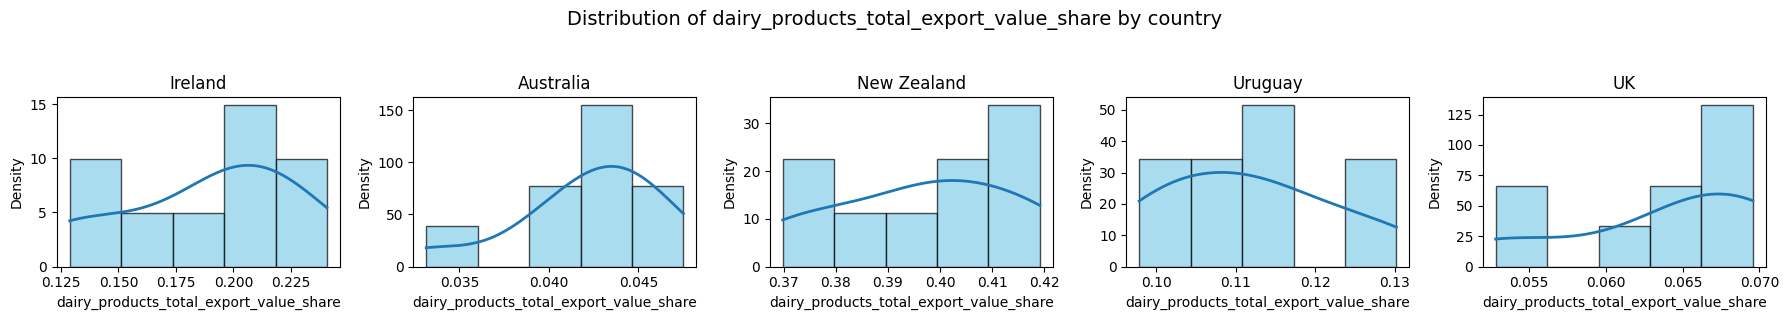

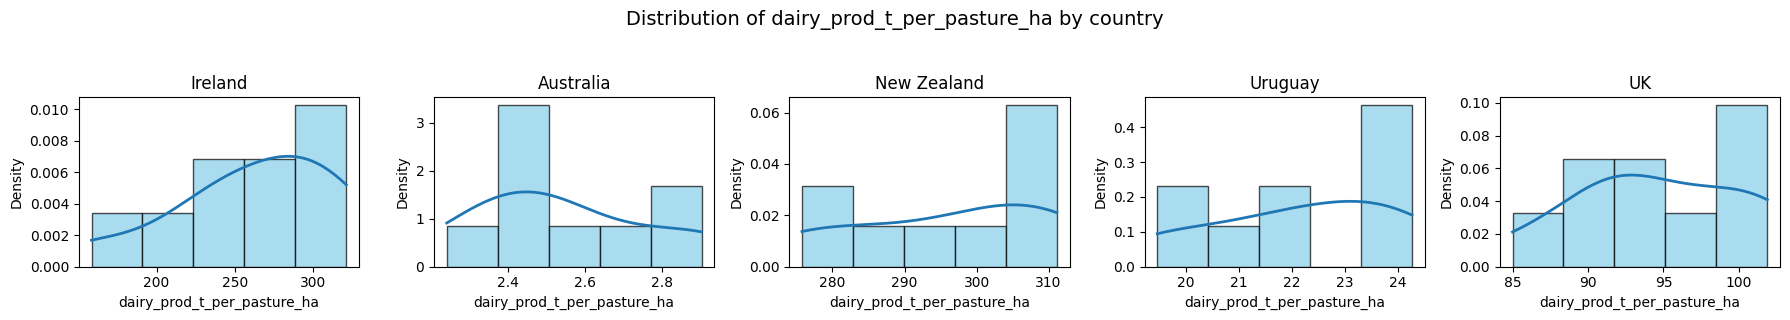

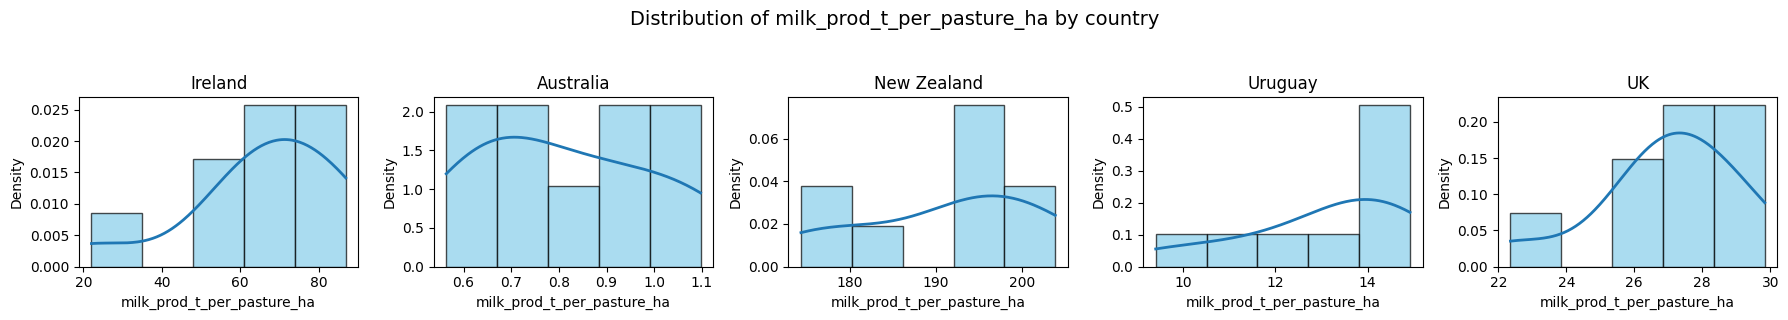

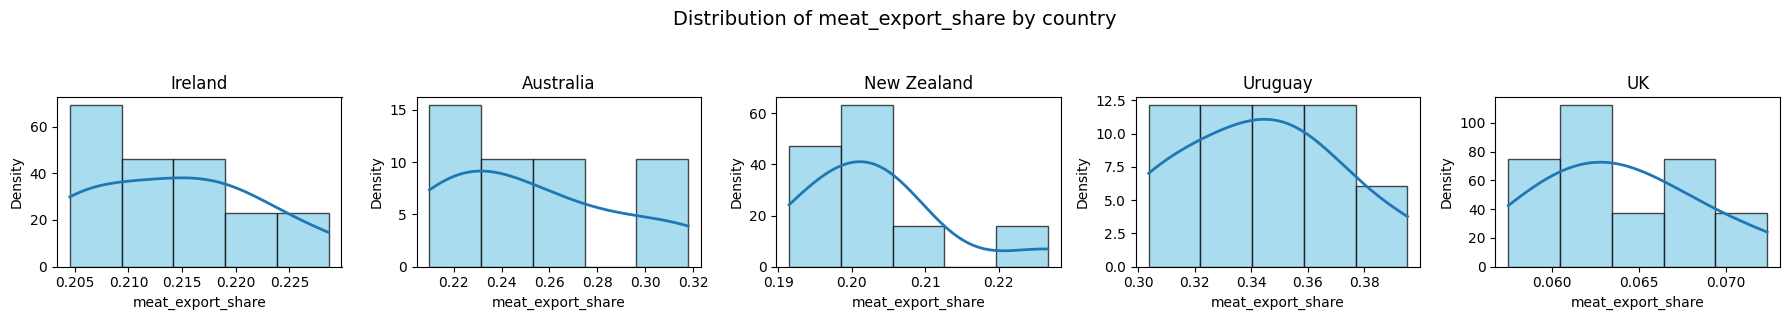

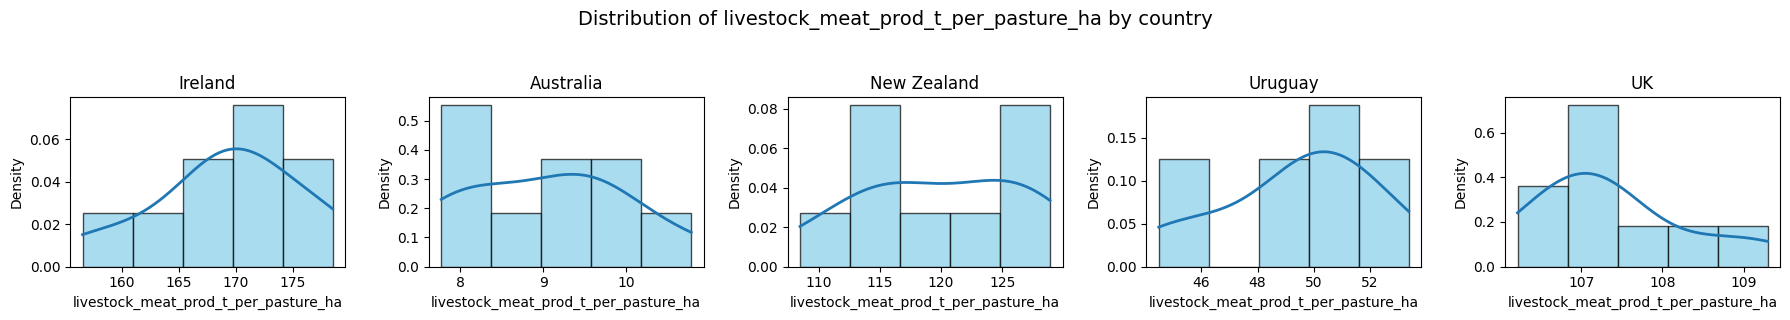

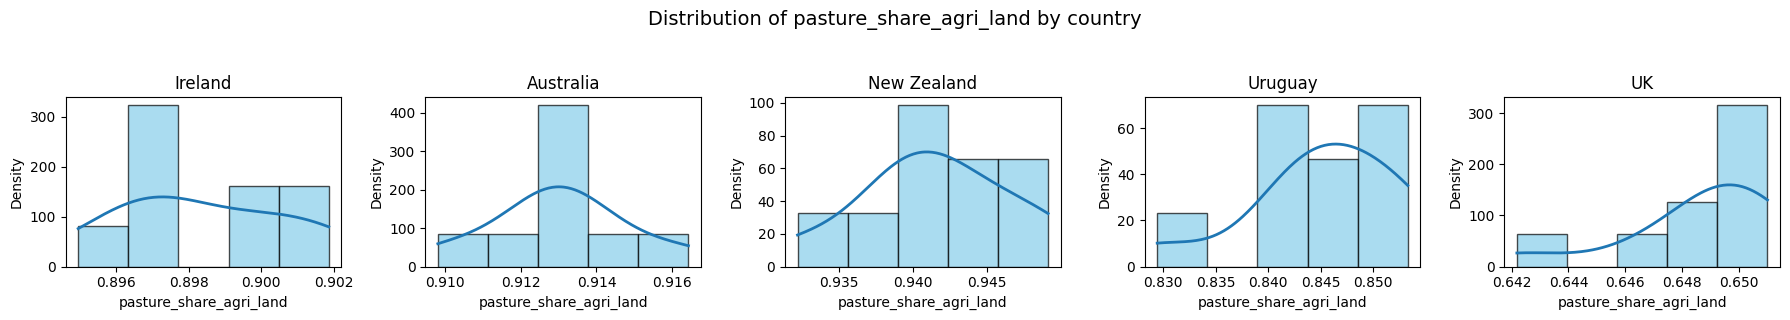

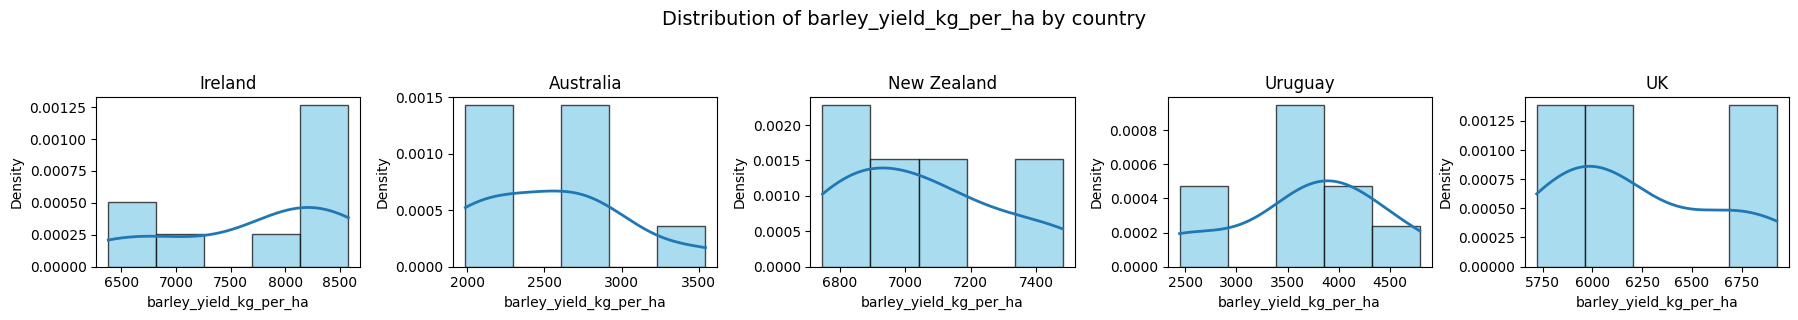

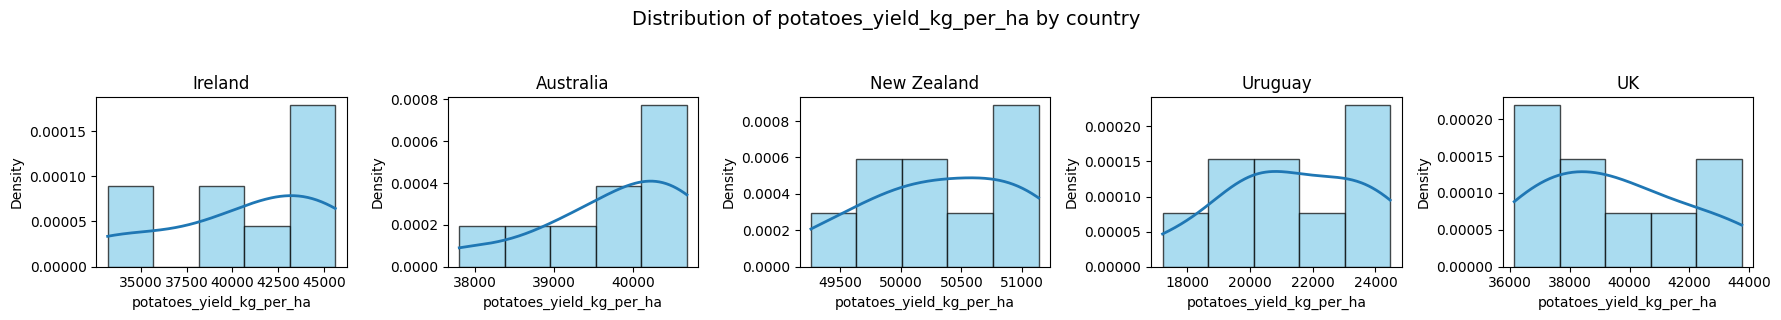

In [88]:
# plot distributions for each selected variable, split by country
for var in main_vars:
    # create one row of plots: one histogram per country
    fig, axes = plt.subplots(1, len(countries_selected), figsize=(18, 3))
    
    # Loop through each country
    for ax, country in zip(axes, countries_selected):
        
        # select values for this country and variable
        x = stats_df.loc[stats_df["country_name"] == country, var].dropna()
        
        # plot histogram
        ax.hist(x, bins=5, density=True, color="skyblue", edgecolor="black", alpha=0.7)
        
        # add KDE curve only if there is enough variation in the data
        if len(x) > 1 and x.nunique() > 1:
            kde = gaussian_kde(x)
            x_grid = np.linspace(x.min(), x.max(), 200)
            ax.plot(x_grid, kde(x_grid), linewidth=2)
        
        # shorten UK name in plot title
        title = "UK" if country == "United Kingdom of Great Britain and Northern Ireland" else country
        
        ax.set_title(title)
        ax.set_xlabel(var)
        ax.set_ylabel("Density")
    
    fig.suptitle(f"Distribution of {var} by country", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

Most country-variable combinations had p-values above 0.05, meaning we failed to reject the null hypothesis of normality. Therefore, most variables can be treated as approximately normally distributed for the purpose of parametric testing.

The exceptions were:
- UK dairy products export value share: p = 0.027, not normally distributed
- UK pasture share of agricultural land: p = 0.0264, not normally distributed

This means that for pairwise comparisons between Ireland and the UK, Mann-Whitney U test should be used for these two variables. For the other pairwise comparisons, Welch's t-test can be used because both compared country groups are approximately normally distributed (Z-test is not considered here, because the sample size is very small, way less than 30 observations).

For one-way ANOVA, the normality assumption should hold for all country groups included in the comparison. Therefore, ANOVA is suitable for the variables where all five countries are approximately normally distributed. Dairy products export value share and pasture share of agricultural land will be excluded from ANOVA because the UK values for these variables are not normally distributed.

## Pairwise comparison: Ireland vs. each peer country

The next step is to compare Ireland with each peer country separately.

The comparisons are:
- Ireland vs. Australia
- Ireland vs. New Zealand
- Ireland vs. Uruguay
- Ireland vs. United Kingdom

For each selected variable, the choice of test is based on the Shapiro-Wilk normality results:
- If both countries are normally distributed, Welch's t-test is used
- If at least one country is not normally distributed, Mann-Whitney U test is used

Welch's t-test is used instead of Student's t-test because it does not require the assumption of equal variances.

The hypotheses for Welch's t-test are:
- H0: The mean value is equal between Ireland and the comparison country
- H1: The mean value is different between Ireland and the comparison country

The hypotheses for Mann-Whitney U test are:
- H0: The distributions of the two countries are the same
- H1: The distributions of the two countries are different

In [105]:
pairwise_results = []

# function to make reject/fail to reject decision
def make_decision(p_value):
    
    # if p-value is missing/invalid, do not make a hypothesis decision
    if pd.isna(p_value):
        return "No decision"
    
    # standard hypothesis test decision
    if p_value < alpha:
        return "Reject H0"
    else:
        return "Fail to reject H0"


# Loop through each selected variable
for var in main_vars:
    # Loop through each peer country
    for peer in consensus_neighbours:
        
        # get Ireland and peer country values
        ireland_values = stats_df.loc[stats_df["country_name"] == "Ireland", var].dropna()
        peer_values = stats_df.loc[stats_df["country_name"] == peer, var].dropna()
        
        # get normality decisions from the Shapiro-Wilk results
        ireland_normal = normality_results.loc[(normality_results["variable"] == var) & (normality_results["country"] == "Ireland"),
            "normality_decision"].iloc[0]
        peer_normal = normality_results.loc[(normality_results["variable"] == var) & (normality_results["country"] == peer), 
            "normality_decision"].iloc[0]
        
        # if both groups are normal, use Welch's t-test
        if ireland_normal == "Normal" and peer_normal == "Normal":
            test_name = "Welch's t-test"
            statistic, p_value = stats.ttest_ind(ireland_values, peer_values, equal_var=False)
        
        # if at least one group is not normal, use Mann-Whitney U test
        else:
            test_name = "Mann-Whitney U test"
            statistic, p_value = stats.mannwhitneyu(ireland_values, peer_values, alternative="two-sided")
        
        # save the result
        pairwise_results.append({
            "variable": var,
            "comparison": "Ireland vs " + peer,
            "test": test_name,
            "Ireland mean": ireland_values.mean(),
            "Peer mean": peer_values.mean(),
            "statistic": statistic,
            "p_value": p_value,
            "decision": make_decision(p_value)
        })

# convert results to dataframe
pairwise_results = pd.DataFrame(pairwise_results)

# round numeric columns for easier reading
pairwise_results["Ireland mean"] = pairwise_results["Ireland mean"].round(4)
pairwise_results["Peer mean"] = pairwise_results["Peer mean"].round(4)
pairwise_results["statistic"] = pairwise_results["statistic"].round(4)
pairwise_results["p_value"] = pairwise_results["p_value"].round(6)

pairwise_results

,variable,comparison,test,Ireland mean,Peer mean,statistic,p_value,decision
0,dairy_products_total_export_value_share,Ireland vs Australia,Welch's t-test,0.1886,0.0422,11.2193,0.000003,Reject H0
1,dairy_products_total_export_value_share,Ireland vs New Zealand,Welch's t-test,0.1886,0.3967,-14.5508,0.000000,Reject H0
2,dairy_products_total_export_value_share,Ireland vs Uruguay,Welch's t-test,0.1886,0.1117,5.7023,0.000263,Reject H0
3,dairy_products_total_export_value_share,Ireland vs United Kingdom of Great Britain and...,Mann-Whitney U test,0.1886,0.0637,81.0000,0.000412,Reject H0
4,dairy_prod_t_per_pasture_ha,Ireland vs Australia,Welch's t-test,262.3414,2.5526,15.1156,0.000000,Reject H0
5,dairy_prod_t_per_pasture_ha,Ireland vs New Zealand,Welch's t-test,262.3414,295.8950,-1.8836,0.091628,Fail to reject H0
6,dairy_prod_t_per_pasture_ha,Ireland vs Uruguay,Welch's t-test,262.3414,22.1787,13.9657,0.000001,Reject H0
7,dairy_prod_t_per_pasture_ha,Ireland vs United Kingdom of Great Britain and...,Welch's t-test,262.3414,94.7561,9.6915,0.000009,Reject H0
8,milk_prod_t_per_pasture_ha,Ireland vs Australia,Welch's t-test,66.0097,0.8149,9.8861,0.000009,Reject H0
9,milk_prod_t_per_pasture_ha,Ireland vs New Zealand,Welch's t-test,66.0097,191.0560,-16.6866,0.000000,Reject H0


Most pairwise comparisons produced p-values below 0.05, meaning the null hypothesis was rejected. This suggests that although these countries were grouped with Ireland during clustering, they are not statistically identical to Ireland across individual agricultural indicators.

For dairy products total export value share, Ireland differed significantly from all four peer countries. Ireland's mean dairy export share (0.1886) was lower than New Zealand's (0.3967) but higher than Australia (0.0422), Uruguay (0.1117) and the United Kingdom (0.0637). This shows that New Zealand had a much stronger dairy export orientation than Ireland, while the other peer countries had lower dairy export shares.

For dairy production per pasture hectare, Ireland differed significantly from Australia, Uruguay and the United Kingdom. However, Ireland did not differ significantly from New Zealand, as the p-value was above 0.05. This suggests that New Zealand is the closest peer country to Ireland for this dairy production intensity indicator.

For milk production per pasture hectare, all comparisons were statistically significant. Ireland had much higher milk production per pasture hectare than Australia, Uruguay and the United Kingdom, but much lower than New Zealand. This indicates that Ireland and New Zealand are both dairy-relevant countries, but New Zealand's milk production intensity is substantially higher.

For meat export share, Ireland differed significantly from all four peer countries. Ireland's mean meat export share was closest to New Zealand but still significantly different. Uruguay had the highest meat export share, while the United Kingdom had the lowest.

For livestock meat production per pasture hectare, all comparisons were statistically significant. Ireland had a higher mean value than Australia, New Zealand, Uruguay and the United Kingdom. This suggests that Ireland's livestock meat production intensity is relatively high within this peer group.

For pasture share of agricultural land, Ireland differed significantly from all four peer countries. Ireland's pasture share was lower than Australia and New Zealand, higher than Uruguay, and much higher than the United Kingdom. This indicates that all countries in the peer group are pasture-relevant, but their agricultural land structures are still statistically different.

For barley yield, Ireland differed significantly from all four peer countries. Ireland had the highest mean barley yield among the compared countries.

For potato yield, Ireland did not differ significantly from Australia or the United Kingdom, as their p-values were above 0.05. However, Ireland differed significantly from New Zealand and Uruguay. This suggests that potato yield is one of the variables where Ireland is more similar to some of its peer countries.

Overall, the pairwise tests show that the clustering results identified countries with broadly similar agricultural profiles, but individual variables still differed significantly in many cases. The closest similarities appeared in dairy production per pasture hectare between Ireland and New Zealand, and in potato yield between Ireland, Australia and the United Kingdom. The strongest differences appeared in dairy export share, milk production intensity, livestock meat production intensity, barley yield and pasture share of agricultural land.

## One-way ANOVA across Ireland and consensus peer countries

One-way ANOVA is used to compare the mean values of selected variables across Ireland and its four peer countries: Australia, New Zealand, Uruguay and the United Kingdom.

The hypotheses are:
- H0: The mean value is equal across all five countries
- H1: At least one country has a different mean value

ANOVA is applied only to variables where all five country groups were approximately normally distributed according to the Shapiro-Wilk test. Therefore, dairy products export value share and pasture share of agricultural land were excluded from ANOVA because the UK group was not normally distributed for these variables.

The ANOVA results show whether there is an overall statistically significant difference between the countries. They do not show which specific countries differ from Ireland, so the pairwise tests above are used together with ANOVA to provide more detailed interpretation.

In [106]:
anova_results = []

# select only variables where all country groups were normal
anova_vars = []

for var in main_vars:
    var_normality = normality_results.loc[normality_results["variable"] == var, "normality_decision"]
    
    if (var_normality == "Normal").all():
        anova_vars.append(var)

# run one-way ANOVA for each suitable variable
for var in anova_vars:
    
    groups = [stats_df.loc[stats_df["country_name"] == country, var].dropna() for country in consensus_neighbours]
    
    f_statistic, p_value = stats.f_oneway(*groups)
    
    anova_results.append({
        "variable": var,
        "test": "One-way ANOVA",
        "countries_compared": "Ireland, Australia, New Zealand, Uruguay, UK",
        "F_statistic": f_statistic,
        "p_value": p_value,
        "decision": make_decision(p_value)
    })

anova_results = pd.DataFrame(anova_results)

anova_results["F_statistic"] = anova_results["F_statistic"].round(4)
anova_results["p_value"] = anova_results["p_value"].round(6)

anova_results

,variable,test,countries_compared,F_statistic,p_value,decision
0,dairy_prod_t_per_pasture_ha,One-way ANOVA,"Ireland, Australia, New Zealand, Uruguay, UK",2769.4408,0.0,Reject H0
1,milk_prod_t_per_pasture_ha,One-way ANOVA,"Ireland, Australia, New Zealand, Uruguay, UK",2354.9814,0.0,Reject H0
2,meat_export_share,One-way ANOVA,"Ireland, Australia, New Zealand, Uruguay, UK",190.9232,0.0,Reject H0
3,livestock_meat_prod_t_per_pasture_ha,One-way ANOVA,"Ireland, Australia, New Zealand, Uruguay, UK",1693.2643,0.0,Reject H0
4,barley_yield_kg_per_ha,One-way ANOVA,"Ireland, Australia, New Zealand, Uruguay, UK",148.8801,0.0,Reject H0
5,potatoes_yield_kg_per_ha,One-way ANOVA,"Ireland, Australia, New Zealand, Uruguay, UK",388.0853,0.0,Reject H0


For all tested variables, the p-values were below 0.05. Therefore, the null hypothesis was rejected for each variable. This means that there is statistically significant evidence that at least one country differs from the others for each of these agricultural indicators.

The significant ANOVA results suggest that, although these countries were repeatedly grouped with Ireland during clustering, they are not identical when individual variables are tested separately. The consensus group captures broad agricultural similarity, but important differences remain in production intensity, export structure and crop yields.

The strongest ANOVA differences were found for dairy production per pasture hectare, milk production per pasture hectare and livestock meat production per pasture hectare, as shown by the large F-statistics. This indicates that production intensity varies strongly across the countries in the consensus group.

Meat export share, barley yield and potato yield also showed statistically significant differences across the five countries. Therefore, these variables also contribute to differences within the consensus peer group.

It is important to note that ANOVA only shows that at least one country mean is different. It does not identify which specific countries differ from Ireland. For this reason, the pairwise Ireland-vs-peer tests are used together with ANOVA to interpret the specific differences between Ireland and each peer country.

Note: p-values displayed as 0.0 are very small rounded values and should be interpreted as p < 0.0001, not as exact zero.

## ANOVA as cluster-level validation

We also want to use one-way ANOVA to assess whether the Ireland clusters produced by different clustering methods are statistically similar for each selected agricultural variable.

This provides a cluster-level validation step. If ANOVA is not significant, there is no evidence of a difference in country means within that Ireland cluster for the selected variable. If ANOVA is significant, at least one country in the cluster differs from the others, suggesting that the cluster is agriculturally similar overall but not statistically identical for that variable.

The first two clustering results produced the same Ireland cluster, so they are treated as one repeated cluster pattern rather than tested twice.

For each cluster pattern and variable, Shapiro-Wilk normality is checked for all countries in the group. ANOVA is applied only when all country groups are approximately normally distributed.

In [107]:
# use the full recent country-year dataframe for cluster-pattern ANOVA
# (this is important because Cluster pattern 3 includes countries that are not in the consensus peer group)
anova_source_df = raw_df.copy()

# unique Ireland cluster groups from the clustering results
ireland_cluster_groups = {
    "Cluster pattern 1/2": ["Australia", "Ireland", "New Zealand", "Uruguay"],
    "Cluster pattern 3": ["Austria", "Denmark", "France", "Germany", "Ireland", "Luxembourg", "New Zealand", "Sweden", 
                          "United Kingdom of Great Britain and Northern Ireland"],
    "Cluster pattern 4": ["Ireland", "New Zealand", "United Kingdom of Great Britain and Northern Ireland"]
}

# create a list to store ANOVA results
cluster_anova_results = []

# Loop through each Ireland cluster pattern
for cluster_name, cluster_countries in ireland_cluster_groups.items():    
    # Loop through each selected variable
    for var in main_vars:

        # track whether ANOVA can be applied
        normality_ok = True
        data_ok = True
        normality_notes = []    # list to store Shapiro-Wilk p-values for each country
        groups = []             # list to store the actual values for each country

        # Loop through each country in the current cluster pattern
        for country in cluster_countries:
            # select the annual values for the current country and variable
            values = anova_source_df.loc[anova_source_df["country_name"] == country, var].dropna()
            
            # if there are too few observations, ANOVA should not be applied
            if len(values) < 3:
                data_ok = False
                normality_ok = False
                normality_notes.append(country + ": not enough data")
                continue
            
            # run the Shapiro-Wilk test to check normality for this country-variable group
            shapiro_stat, shapiro_p = stats.shapiro(values)

            # if Shapiro-Wilk returns NaN, something is wrong with the data
            if pd.isna(shapiro_p):
                data_ok = False
                normality_ok = False
                normality_notes.append(country + ": p=NaN")
                continue
                
            # if the Shapiro-Wilk p-value is below alpha, normality is rejected
            if shapiro_p < alpha:
                normality_ok = False
            
            # store the country-level normality result as text
            normality_notes.append(country + ": p=" + str(round(shapiro_p, 4)))
            # add this country's values to the list of groups for ANOVA
            groups.append(values)
        
        # Run ANOVA only if data exists and all groups are normally distributed
        if data_ok and normality_ok:
            f_statistic, p_value = stats.f_oneway(*groups)
            
            # Make decision only if p-value is valid
            if pd.isna(p_value):
                decision = "ANOVA not applied - invalid p-value"
            else:
                decision = make_decision(p_value)
                
        # if at least one country group failed the normality check, do not run ANOVA
        else:
            # np.nan is used because no ANOVA statistic or p-value was calculated
            f_statistic = np.nan
            p_value = np.nan
            if not data_ok:
                decision = "ANOVA not applied - insufficient or missing data"
            else:
                decision = "ANOVA not applied - normality assumption not met"

        # save the result for this cluster pattern and variable
        cluster_anova_results.append({
            "cluster_pattern": cluster_name,
            "variable": var,
            "countries_n": len(cluster_countries),
            "normality_check": "; ".join(normality_notes),
            "F_statistic": f_statistic,
            "p_value": p_value,
            "decision": decision
        })

# convert the list of dictionaries into a dataframe for easier viewing
cluster_anova_results = pd.DataFrame(cluster_anova_results)
# round ANOVA statistics and p-values to make the output table easier to read
cluster_anova_results["F_statistic"] = cluster_anova_results["F_statistic"].round(4)
cluster_anova_results["p_value"] = cluster_anova_results["p_value"].round(4)

cluster_anova_results

,cluster_pattern,variable,countries_n,normality_check,F_statistic,p_value,decision
0,Cluster pattern 1/2,dairy_products_total_export_value_share,4,Australia: p=0.2656; Ireland: p=0.3576; New Ze...,428.2573,0.0,Reject H0
1,Cluster pattern 1/2,dairy_prod_t_per_pasture_ha,4,Australia: p=0.3136; Ireland: p=0.4809; New Ze...,301.8123,0.0,Reject H0
2,Cluster pattern 1/2,milk_prod_t_per_pasture_ha,4,Australia: p=0.4895; Ireland: p=0.1734; New Ze...,534.8872,0.0,Reject H0
3,Cluster pattern 1/2,meat_export_share,4,Australia: p=0.2257; Ireland: p=0.6187; New Ze...,55.1959,0.0,Reject H0
4,Cluster pattern 1/2,livestock_meat_prod_t_per_pasture_ha,4,Australia: p=0.5884; Ireland: p=0.6662; New Ze...,1821.7044,0.0,Reject H0
5,Cluster pattern 1/2,pasture_share_agri_land,4,Australia: p=0.6929; Ireland: p=0.631; New Zea...,669.1693,0.0,Reject H0
6,Cluster pattern 1/2,barley_yield_kg_per_ha,4,Australia: p=0.2838; Ireland: p=0.071; New Zea...,143.7961,0.0,Reject H0
7,Cluster pattern 1/2,potatoes_yield_kg_per_ha,4,Australia: p=0.1656; Ireland: p=0.1565; New Ze...,185.7129,0.0,Reject H0
8,Cluster pattern 3,dairy_products_total_export_value_share,9,Austria: p=0.2434; Denmark: p=0.7965; France: ...,NaN,NaN,ANOVA not applied - normality assumption not met
9,Cluster pattern 3,dairy_prod_t_per_pasture_ha,9,Austria: p=0.1044; Denmark: p=0.1686; France: ...,554.7982,0.0,Reject H0


For Cluster pattern 1/2, ANOVA was applied to all selected variables, and the null hypothesis was rejected in every case. This means that Australia, Ireland, New Zealand and Uruguay were not statistically equal across the tested indicators, even though they were grouped together by two clustering solutions.

For Cluster pattern 3, ANOVA could not be applied to some variables because the normality assumption was not met. For the variables where ANOVA was applied, the null hypothesis was again rejected. This suggests that the wider European-focused Ireland cluster also contained statistically significant differences between countries.

For Cluster pattern 4, ANOVA was not applied to dairy products export value share and pasture share of agricultural land because the normality assumption was not met. For the remaining variables, the null hypothesis was rejected. Therefore, even the smaller cluster containing Ireland, New Zealand and the United Kingdom showed significant differences across the tested indicators.

Overall, the ANOVA results show that the Ireland clusters identified during clustering are not statistically homogeneous across individual agricultural variables. This does not mean the clustering results were invalid. Rather, it shows that clustering captured broad multivariate similarity, while inferential testing revealed that individual indicators still differ significantly between countries.

The results also support the decision to use both clustering and inferential statistics. Clustering helped identify countries with broadly similar agricultural profiles to Ireland, while ANOVA showed that these similarities should be interpreted cautiously and variable by variable.

It is also important to note that ANOVA only shows that at least one country mean differs within a cluster. It does not identify which country differs from Ireland specifically. Therefore, the pairwise Ireland-vs-country tests are needed alongside ANOVA to interpret Ireland's specific similarities and differences.

Note: p-values displayed as 0.0 are very small rounded values and should be interpreted as p < 0.0001, not as exact zero.

## Chi-square test of independence

The Chi-square test is used to analyse categorical variables. Here, we will use it to check whether the Ireland consensus peer-group has a different export profile compared with the other countries in the dataset.

We create a categorical variable called `export_profile`:
- `Dairy-dominant` if dairy products export value share is greater than or equal to meat export share
- `Meat-dominant` if meat export share is greater than dairy products export value share

The countries are also divided into two groups:
- `Ireland consensus group`: Ireland, Australia, New Zealand, Uruguay and the United Kingdom
- `Other countries`: all other countries in the dataset

The hypotheses are:
- H0: Export profile is independent of country group
- H1: Export profile is associated with country group

This test helps assess whether the Ireland-like consensus group identified during clustering has a distinctive dairy/meat export profile compared with the rest of the dataset.

The Chi-square test is appropriate because both variables are categorical. We check the expected frequency table to make sure that the expected cell counts are large enough for the test to be reliable.

In [109]:
# create a copy of the full recent dataset
# (we use raw_df here, not only stats_df, because Chi-square needs enough observations in each category)
chi_df = raw_df.copy()

# define the Ireland consensus group
ireland_consensus_countries = ["Ireland"] + consensus_neighbours

# create a categorical variable for consensus group membership
chi_df["consensus_group"] = np.where(
    chi_df["country_name"].isin(ireland_consensus_countries),
    "Ireland consensus group",
    "Other countries"
)

# create a categorical export profile variable
# each country-year is classified as either dairy-dominant or meat-dominant
chi_df["export_profile"] = np.where(
    chi_df["dairy_products_total_export_value_share"] >= chi_df["meat_export_share"],
    "Dairy-dominant",
    "Meat-dominant"
)

# create the observed frequency table
# rows are country groups and columns are export profile categories
observed = pd.crosstab(chi_df["consensus_group"], chi_df["export_profile"])

observed

export_profile,Dairy-dominant,Meat-dominant
consensus_group,,
Ireland consensus group,16,29
Other countries,157,140


In [110]:
# run Chi-square test of independence
chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)

# convert expected frequencies into a dataframe for easier checking
expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)
expected_df

export_profile,Dairy-dominant,Meat-dominant
consensus_group,,
Ireland consensus group,22.763158,22.236842
Other countries,150.236842,146.763158


In [111]:
# store Chi-square result in a readable table
chi_square_result = pd.DataFrame([{
    "test": "Chi-square test of independence",
    "comparison": "Ireland consensus cluster vs other countries",
    "categorical_variable": "export_profile",
    "chi2_statistic": chi2_stat,
    "degrees_of_freedom": dof,
    "p_value": p_value,
    "decision": make_decision(p_value)
}])

# round values for display
chi_square_result["chi2_statistic"] = chi_square_result["chi2_statistic"].round(4)
chi_square_result["p_value"] = chi_square_result["p_value"].round(4)

chi_square_result

,test,comparison,categorical_variable,chi2_statistic,degrees_of_freedom,p_value,decision
0,Chi-square test of independence,Ireland consensus cluster vs other countries,export_profile,4.0157,1,0.0451,Reject H0


The observed freqyency table shows that the Ireland consensus group has 16 dairy-dominant country-year observations and 29 meat-dominant observations. Other countries have 157 dairy-dominant observations and 140 meat-dominant observations.

The expected frequency table was also checked. All expected counts were above 5, so the Chi-square test assumption about expected frequencies was satisfied.

The Chi-square test produced a test statistic of 4.0157 with 1 degree of freedom and a p-value of 0.0451. Since the p-value is below the significance level of 0.05, the null hypothesis is rejected.

This means there is statistically significant evidence that export profile is associated with country group. In other words, the distribution of dairy-dominant and meat-dominant observations differs between the Ireland consensus group and the other countries.

The Ireland consensus group had more meat-dominant observations than expected under independence, while the other countries had slightly more dairy-dominant observations than expected. This suggests that the Ireland consensus group has a somewhat more meat-oriented export profile compared with the rest of the countries in the dataset.

However, the p-value is close to 0.05, so this result should be interpreted cautiously. It suggests an association between group membership and export profile, but the evidence is not as strong as in many of the pairwise numerical tests.